# ForceGNN Usage Example

This notebook demonstrates how to use the refactored `GNN_inference` module step-by-step.


In [31]:
# Import everything from the module
%load_ext autoreload
%autoreload 2

# Import everything from the module
import sys
sys.path.append('..')

import importlib
import torch
import torch.nn as nn

import torch_inference
importlib.reload(torch_inference)
from torch_inference import *
import functorch
import json
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pickle
clrs = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728', '#9467bd', '#8c564b', '#e377c2', '#7f7f7f', '#bcbd22', '#17becf']
datadir = "/Users/billiemeadowcroft/Dropbox/PostDocCode/GNN/My_GNN/Data_CSVs/Experimental"
plotsdir = "/Users/billiemeadowcroft/Dropbox/PostDocCode/GNN/My_GNN/CellStatTransitionPytorch/Plots/"



The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [47]:
class ForceGNN(nn.Module):
    """
    Graph Neural Network for learning force decomposition.
    
    Forces are decomposed into:
    - F_env: Environmental/external forces (position-dependent, uses node_features[:, :2])
    - F_r: Pairwise interaction forces (distance-dependent)
    - Memory/drag term using Jacobian-vector product of F_env and tau_raw
    
    Node features: [x, y, vx, vy, type] - positions, velocities, and particle type
    """
    
    def __init__(self, hidden_dim=32, tau_init=1.0):
        super(ForceGNN, self).__init__()

        self.r_mean = 0.0
        self.r_std  = 1.0
        self.y_mean = np.array([0.0, 0.0], dtype=np.float32)
        self.y_std  = np.array([1.0, 1.0], dtype=np.float32)
        self.x_mean = np.array([0.0, 0.0], dtype=np.float32)
        self.x_std  = float(1.0)

        self.interaction_net = nn.Sequential(
            nn.Linear(1, hidden_dim),
            nn.SiLU(),                          # SiLU == Swish
            nn.LayerNorm(hidden_dim),
            nn.Linear(hidden_dim, hidden_dim),
            nn.SiLU(),
            nn.LayerNorm(hidden_dim),
            nn.Linear(hidden_dim, hidden_dim),
            nn.SiLU(),
            nn.Linear(hidden_dim, 1)
        )

        # Learnable memory timescale
        self.tau_raw = nn.Parameter(
            torch.tensor(tau_init, dtype=torch.float32)
        )

    def _jvp(self, positions, velocities):
        """
        Compute Jacobian-vector product (∂F_env/∂x) · v using
        forward-mode AD via torch.func.jvp.
        
        Parameters:
        -----------
        positions  : (N, 2) position tensor
        velocities : (N, 2) velocity tensor (the tangent vector)
        
        Returns:
        --------
        Jv : (N, 2) JVP result
        """

        def f(pos):
            return self.env_net(pos)

        _, Jv = torch.func.jvp(f, (positions,), (velocities,))
        return Jv

    def forward(self, node_features, edge_indices, edge_features, return_components=False):
        """
        Forward pass of the model.
        
        Parameters:
        -----------
        node_features  : Tensor (N, 5) [x, y, vx, vy, type]
        edge_indices   : Tensor (2, E) edge connections
        edge_features  : Tensor (E, 3) [r, dx/r, dy/r]
        return_components : bool
            If True, return individual force components
        
        Returns:
        --------
        F_total or tuple of (F_total, F_r_aggregated, F_drag, F_env)
        """
        _y = getattr(self, "y_std", 1.0)
        y_std = float(np.asarray(_y).flat[0]) if np.ndim(_y) != 0 else float(_y)
        if y_std == 0.0:
            y_std = 1.0
        
        _x = getattr(self, "x_std", 1.0)
        x_std = float(np.asarray(_x).flat[0]) if np.ndim(_x) != 0 else float(_x)
        if x_std == 0.0:
            x_std = 1.0

        # Extract positions and velocities
        positions  = node_features[:, :2]
        velocities = node_features[:, 2:4]

        # Environmental force
        #F_env = self.env_net(positions)

        # # Pairwise interaction force
        if edge_indices.shape[1] > 0:
            edge_distances  = edge_features[:, 0:1]
            F_r_scalar      = self.interaction_net(edge_distances)
            edge_unit_vectors = edge_features[:, 1:3]
            F_r_vector      = F_r_scalar*edge_unit_vectors

            target_indices  = edge_indices[1, :]
            N = node_features.shape[0]
            F_r_aggregated  = torch.zeros(N, 2, dtype=node_features.dtype, device=node_features.device)
            F_r_aggregated.scatter_add_(
                0,
                target_indices.long().unsqueeze(1).expand_as(F_r_vector),
                F_r_vector
            )
        else:
            F_r_aggregated = torch.zeros_like(positions)

        # (∂F_env/∂x)·v
        #Jv = self._jvp(positions, velocities)

        #Jv = self._jvp(positions, velocities)
        vel_term =  - (1.0/self.tau_raw)*velocities / y_std #self.tau_raw*Jv/ x_std 
        F_drag = vel_term * (2/3)

        # Total force
        F_total = F_drag  + F_r_aggregated # F_env + 

        if return_components:
            return F_total, F_drag, F_r_aggregated # F_env ,
        return F_total
    
class ForceGNN_FintDot(nn.Module):
    """
    Graph Neural Network for learning force decomposition.
    
    Forces are decomposed into:
    - F_env: Environmental/external forces (position-dependent, uses node_features[:, :2])
    - F_r: Pairwise interaction forces (distance-dependent)
    - Memory/drag term using Jacobian-vector product of F_env and tau_raw
    
    Node features: [x, y, vx, vy, type] - positions, velocities, and particle type
    """
    
    def __init__(self, hidden_dim=32, tau_init=1.0):
        super(ForceGNN_FintDot, self).__init__()

        self.r_mean = 0.0
        self.r_std  = 1.0
        self.y_mean = np.array([0.0, 0.0], dtype=np.float32)
        self.y_std  = np.array([1.0, 1.0], dtype=np.float32)
        self.x_mean = np.array([0.0, 0.0], dtype=np.float32)
        self.x_std  = float(1.0)

        self.interaction_net = nn.Sequential(
            nn.Linear(1, hidden_dim),
            nn.SiLU(),                          # SiLU == Swish
            nn.LayerNorm(hidden_dim),
            nn.Linear(hidden_dim, hidden_dim),
            nn.SiLU(),
            nn.LayerNorm(hidden_dim),
            nn.Linear(hidden_dim, hidden_dim),
            nn.SiLU(),
            nn.Linear(hidden_dim, 1)
        )

        # Learnable memory timescale
        self.tau_raw = nn.Parameter(
            torch.tensor(tau_init, dtype=torch.float32)
        )

    def _jvp(self, positions, velocities):
        """
        Compute Jacobian-vector product (∂F_env/∂x) · v using
        forward-mode AD via torch.func.jvp.
        
        Parameters:
        -----------
        positions  : (N, 2) position tensor
        velocities : (N, 2) velocity tensor (the tangent vector)
        
        Returns:
        --------
        Jv : (N, 2) JVP result
        """

        def f(pos):
            return self.env_net(pos)

        _, Jv = torch.func.jvp(f, (positions,), (velocities,))
        return Jv
    
    def _dfdr(self, edge_distances):
        """df/dr per edge via jvp with unit tangent."""
        def f(r):
            return self.interaction_net(r)  # (E, 1)
        _, dfdr = torch.func.jvp(f, (edge_distances,), (torch.ones_like(edge_distances),))
        return dfdr  # (E, 1)

    def forward(self, node_features, edge_indices, edge_features, return_components=False):
        """
        Forward pass of the model.

        Parameters:
        -----------
        node_features      : Tensor (N, 5) [x, y, vx, vy, type]
        edge_indices       : Tensor (2, E) edge connections
        edge_features      : Tensor (E, 3) [r, dx/r, dy/r]
        vel_edge_features  : Tensor (E, 3) [|dv|, dvx/|dv|, dvy/|dv|]
        return_components  : bool
            If True, return (F_total, F_drag, F_env, F_r_aggregated, F_rdot_aggregated)

        Returns:
        --------
        F_total or tuple
        """
        _y = getattr(self, "y_std", 1.0)
        y_std = float(np.asarray(_y).flat[0]) if np.ndim(_y) != 0 else float(_y)
        if y_std == 0.0:
            y_std = 1.0

        _x = getattr(self, "x_std", 1.0)
        x_std = float(np.asarray(_x).flat[0]) if np.ndim(_x) != 0 else float(_x)
        if x_std == 0.0:
            x_std = 1.0

        _r = getattr(self, "r_std", 1.0)
        r_std = float(np.asarray(_r).flat[0]) if np.ndim(_r) != 0 else float(_r)
        if r_std == 0.0:
            r_std = 1.0

        # Extract positions and velocities
        #positions  = node_features[:, :2]
        velocities = node_features[:, 2:4]


        # Pairwise interaction force + time derivative
        N = node_features.shape[0]
        if edge_indices.shape[1] > 0:
            src_idx = edge_indices[0, :]  # j
            tgt_idx = edge_indices[1, :]  # i  (force acts on i)

            edge_distances    = edge_features[:, 0:1]   # (E, 1)  r_ij
            edge_unit_vectors = edge_features[:, 1:3]   # (E, 2)  r_hat_ij

            # Static pairwise force: f(r) * r_hat
            F_r_scalar = self.interaction_net(edge_distances)  # (E, 1)
            F_r_vector = F_r_scalar * edge_unit_vectors        # (E, 2)

            # Per-edge velocities of i and j
            v_i = velocities[tgt_idx] #/ y_std   # (E, 2)  scaled
            v_j = velocities[src_idx] #/ y_std   # (E, 2)  scaled

            r_ij  = edge_distances.clamp(min=1e-8)    # (E, 1)
            dfdr  = self._dfdr(edge_distances)        # (E, 1)
            #tau   = self.tau_raw / r_std

            # Geometric tensor applied to an arbitrary velocity w: M(r_hat) @ w
            # = [df/dr * (r_hat . w) * r_hat] + [(f/r) * (w - r_hat(r_hat.w))]
            def _Mv(w):
                rdotw = (edge_unit_vectors * w).sum(dim=1, keepdim=True)  # (E,1)
                radial     = dfdr * rdotw * edge_unit_vectors
                transverse = (F_r_scalar / r_ij) * (w - edge_unit_vectors * rdotw)
                return (self.tau_raw/r_std)*(radial + transverse)   # (E, 2)

            F_rdot_vi_edge = _Mv(v_i)   # correlated with noise on i → drag
            F_rdot_vj_edge = _Mv(v_j)   # uncorrelated            → force-like

            # Aggregate onto target nodes
            F_r_aggregated       = torch.zeros(N, 2, dtype=node_features.dtype, device=node_features.device)
            tgt = tgt_idx.long().unsqueeze(1).expand(-1, 2)
            F_r_aggregated.scatter_add_(0, tgt, F_r_vector)
            F_rdot_vi_aggregated = torch.zeros(N, 2, dtype=node_features.dtype, device=node_features.device)
            F_rdot_vj_aggregated = torch.zeros(N, 2, dtype=node_features.dtype, device=node_features.device)
            
            F_rdot_vi_aggregated.scatter_add_(0, tgt, F_rdot_vi_edge)
            F_rdot_vj_aggregated.scatter_add_(0, tgt, F_rdot_vj_edge)
        
        # Drag term: env gradient + interparticle v_i contribution, both corrected by 2/3
        #Jv       = self._jvp(positions, velocities)
        vel_term =  - (1.0 / self.tau_raw) * velocities / y_std #self.tau_raw * Jv / x_std
        F_drag   = (vel_term + F_rdot_vi_aggregated)  * (2/3)  # + F_rdot_vi_aggregated

        # Total force
        F_total = F_drag  + F_r_aggregated - F_rdot_vj_aggregated #+ F_env

        if return_components:
            return F_total, F_drag,  F_r_aggregated #, -F_rdot_vj_aggregated #F_env,
        return F_total
    
class ForceGNN_env(nn.Module):
    """
    Graph Neural Network for learning force decomposition.
    
    Forces are decomposed into:
    - F_env: Environmental/external forces (position-dependent, uses node_features[:, :2])
    - F_r: Pairwise interaction forces (distance-dependent)
    - Memory/drag term using Jacobian-vector product of F_env and tau_raw
    
    Node features: [x, y, vx, vy, type] - positions, velocities, and particle type
    """
    
    def __init__(self, hidden_dim=32, tau_init=1.0):
        super(ForceGNN_env, self).__init__()

        self.r_mean = 0.0
        self.r_std  = 1.0
        self.y_mean = np.array([0.0, 0.0], dtype=np.float32)
        self.y_std  = np.array([1.0, 1.0], dtype=np.float32)
        self.x_mean = np.array([0.0, 0.0], dtype=np.float32)
        self.x_std  = float(1.0)

        self.interaction_net = nn.Sequential(
            nn.Linear(1, hidden_dim),
            nn.SiLU(),                          # SiLU == Swish
            nn.LayerNorm(hidden_dim),
            nn.Linear(hidden_dim, hidden_dim),
            nn.SiLU(),
            nn.LayerNorm(hidden_dim),
            nn.Linear(hidden_dim, hidden_dim),
            nn.SiLU(),
            nn.Linear(hidden_dim, 1)
        )

        self.env_net = nn.Sequential(
            nn.Linear(2, hidden_dim), nn.Tanh(),
            nn.Linear(hidden_dim, hidden_dim), nn.Tanh(),
            nn.Linear(hidden_dim, hidden_dim), nn.Tanh(),
            nn.Linear(hidden_dim, 2)
        )

        # Learnable memory timescale
        self.tau_raw = nn.Parameter(
            torch.tensor(tau_init, dtype=torch.float32)
        )

    def _jvp(self, positions, velocities):
        """
        Compute Jacobian-vector product (∂F_env/∂x) · v using
        forward-mode AD via torch.func.jvp.
        
        Parameters:
        -----------
        positions  : (N, 2) position tensor
        velocities : (N, 2) velocity tensor (the tangent vector)
        
        Returns:
        --------
        Jv : (N, 2) JVP result
        """

        def f(pos):
            return self.env_net(pos)

        _, Jv = torch.func.jvp(f, (positions,), (velocities,))
        return Jv

    def forward(self, node_features, edge_indices, edge_features, return_components=False):
        """
        Forward pass of the model.
        
        Parameters:
        -----------
        node_features  : Tensor (N, 5) [x, y, vx, vy, type]
        edge_indices   : Tensor (2, E) edge connections
        edge_features  : Tensor (E, 3) [r, dx/r, dy/r]
        return_components : bool
            If True, return individual force components
        
        Returns:
        --------
        F_total or tuple of (F_total, F_r_aggregated, F_drag, F_env)
        """
        _y = getattr(self, "y_std", 1.0)
        y_std = float(np.asarray(_y).flat[0]) if np.ndim(_y) != 0 else float(_y)
        if y_std == 0.0:
            y_std = 1.0
        
        _x = getattr(self, "x_std", 1.0)
        x_std = float(np.asarray(_x).flat[0]) if np.ndim(_x) != 0 else float(_x)
        if x_std == 0.0:
            x_std = 1.0

        # Extract positions and velocities
        positions  = node_features[:, :2]
        velocities = node_features[:, 2:4]

        # Environmental force
        F_env = self.env_net(positions)

        # # Pairwise interaction force
        if edge_indices.shape[1] > 0:
            edge_distances  = edge_features[:, 0:1]
            F_r_scalar      = self.interaction_net(edge_distances)
            edge_unit_vectors = edge_features[:, 1:3]
            F_r_vector      = F_r_scalar*edge_unit_vectors

            target_indices  = edge_indices[1, :]
            N = node_features.shape[0]
            F_r_aggregated  = torch.zeros(N, 2, dtype=node_features.dtype, device=node_features.device)
            F_r_aggregated.scatter_add_(
                0,
                target_indices.long().unsqueeze(1).expand_as(F_r_vector),
                F_r_vector
            )
        else:
            F_r_aggregated = torch.zeros_like(positions)

        # (∂F_env/∂x)·v
        #Jv = self._jvp(positions, velocities)

        Jv = self._jvp(positions, velocities)
        vel_term =  self.tau_raw*Jv/ x_std - (1.0/self.tau_raw)*velocities / y_std #self.tau_raw*Jv/ x_std 
        F_drag = vel_term * (2/3)

        # Total force
        F_total = F_drag  + F_r_aggregated + F_env #+ 

        if return_components:
            return F_total, F_drag, F_r_aggregated + F_env #
        return F_total

In [40]:
def create_model(hidden_dim=32, tau_init=1.0):
    """
    Create a ForceGNN model.
    
    Parameters:
    -----------
    hidden_dim : int
        Hidden dimension for neural network layers
    
    Returns:
    --------
    ForceGNN
        Initialized model
    """
    model = ForceGNN(hidden_dim=hidden_dim, tau_init=tau_init)
    print(f"ForceGNN model created with hidden_dim={hidden_dim}")
    return model

def create_model_FintDot(hidden_dim=32, tau_init=1.0):
    """
    Create a ForceGNN model.
    
    Parameters:
    -----------
    hidden_dim : int
        Hidden dimension for neural network layers
    
    Returns:
    --------
    ForceGNN
        Initialized model
    """
    model = ForceGNN_FintDot(hidden_dim=hidden_dim, tau_init=tau_init)
    print(f"ForceGNN model created with hidden_dim={hidden_dim}")
    return model

def create_model_env(hidden_dim=32, tau_init=1.0):
    """
    Create a ForceGNN model.
    
    Parameters:
    -----------
    hidden_dim : int
        Hidden dimension for neural network layers
    
    Returns:
    --------
    ForceGNN
        Initialized model
    """
    model = ForceGNN_env(hidden_dim=hidden_dim, tau_init=tau_init)
    print(f"ForceGNN model created with hidden_dim={hidden_dim}")
    return model

In [41]:
def save_model(model, filepath, history=None):
    """
    Save a trained ForceGNN (PyTorch) model.

    Saves three files:
      <filepath>.pt          – model weights (state_dict)
      <filepath>_config.json – architecture hyperparameters needed to reconstruct the model
      <filepath>_norm.json   – normalisation statistics stored on the model
      <filepath>_history.json – training history (optional, if history is provided)

    Parameters
    ----------
    model : ForceGNN
        Trained model.
    filepath : str
        Base path (no extension). Extensions are added automatically.
    history : dict, optional
        Training history returned by train_model().
    """
    if not filepath.endswith('.pt'):
        filepath = filepath + '.pt'

    # --- weights ---
    torch.save(model.state_dict(), filepath)
    print(f"Model weights saved to: {filepath}")

    # --- architecture config ---
    # Infer hidden_dim from the first Linear layer of interaction_net
    hidden_dim = model.interaction_net[0].out_features
    tau_init   = float(model.tau_raw.detach().cpu())   # save current learned value as init hint
    config = {
        "hidden_dim": int(hidden_dim),
        "tau_init":   tau_init,
    }
    config_path = filepath.replace('.pt', '_config.json')
    with open(config_path, 'w') as f:
        json.dump(config, f, indent=2)
    print(f"Model config saved to:  {config_path}")

    # --- normalisation stats ---
    def _to_list(v):
        if isinstance(v, np.ndarray):
            return v.tolist()
        return float(v)

    norm = {
        "r_mean": _to_list(getattr(model, "r_mean", 0.0)),
        "r_std":  _to_list(getattr(model, "r_std",  1.0)),
        "y_mean": _to_list(getattr(model, "y_mean", np.array([0.0, 0.0]))),
        "y_std":  _to_list(getattr(model, "y_std",  np.array([1.0, 1.0]))),  # was scalar default
        "x_mean": _to_list(getattr(model, "x_mean", np.array([0.0, 0.0]))),
        "x_std":  _to_list(getattr(model, "x_std",  1.0)),
    }
    norm_path = filepath.replace('.pt', '_norm.json')
    with open(norm_path, 'w') as f:
        json.dump(norm, f, indent=2)
    print(f"Normalisation stats saved to: {norm_path}")

    # --- history ---
    if history is not None:
        history_path = filepath.replace('.pt', '_history.json')
        # Convert any numpy/torch scalars to plain Python floats for JSON
        clean = {}
        for k, v in history.items():
            if isinstance(v, (list, tuple)):
                clean[k] = [float(x) if not isinstance(x, str) else x for x in v]
            else:
                clean[k] = float(v) if not isinstance(v, str) else v
        with open(history_path, 'w') as f:
            json.dump(clean, f, indent=2)
        print(f"History saved to: {history_path}")

def load_history(filepath):
    """
    Load training history saved by save_model().

    Parameters
    ----------
    filepath : str
        Base path used when saving (with or without .pt extension).

    Returns
    -------
    dict or None
        Training history dict, or None if no history file exists.
    """
    if not filepath.endswith('.pt'):
        filepath = filepath + '.pt'

    history_path = filepath.replace('.pt', '_history.json')

    try:
        with open(history_path, 'r') as f:
            history = json.load(f)
        print(f"History loaded from: {history_path}")
        return history
    except FileNotFoundError:
        print(f"No history file found at: {history_path}")
        return None
    
def load_model(filepath, hidden_dim=None, tau_init=1.0, device=None):
    """
    Load a saved ForceGNN (PyTorch) model.

    Looks for:
      <filepath>.pt           – weights
      <filepath>_config.json  – architecture config (optional if hidden_dim is passed)
      <filepath>_norm.json    – normalisation stats (optional)

    Parameters
    ----------
    filepath : str
        Path to the .pt weights file (with or without the .pt extension).
    hidden_dim : int, optional
        Hidden dimension used when the model was created. If None, reads from
        the saved config file. Required if no config file exists.
    tau_init : float, optional
        Only used as a fallback if no config file is found.
    device : torch.device or str, optional
        Device to load weights onto. Defaults to CPU.

    Returns
    -------
    ForceGNN
        Loaded model in eval() mode.
    """
    if not filepath.endswith('.pt'):
        filepath = filepath + '.pt'

    if device is None:
        device = torch.device('cpu')

    # --- architecture config ---
    config_path = filepath.replace('.pt', '_config.json')
    try:
        with open(config_path, 'r') as f:
            config = json.load(f)
        hidden_dim = hidden_dim or config["hidden_dim"]
        tau_init   = config.get("tau_init", tau_init)
        print(f"Loaded config from: {config_path}")
    except FileNotFoundError:
        if hidden_dim is None:
            raise ValueError(
                f"No config file found at {config_path} and hidden_dim not provided. "
                "Pass hidden_dim explicitly."
            )
        print(f"No config file found; using hidden_dim={hidden_dim}, tau_init={tau_init}")

    # --- reconstruct model ---
    model = ForceGNN(hidden_dim=hidden_dim, tau_init=tau_init)

    # --- load weights ---
    state_dict = torch.load(filepath, map_location=device)
    model.load_state_dict(state_dict)
    print(f"Weights loaded from: {filepath}")

    # --- normalisation stats ---
    norm_path = filepath.replace('.pt', '_norm.json')
    try:
        with open(norm_path, 'r') as f:
            norm = json.load(f)
        model.r_mean = float(norm.get("r_mean", 0.0))
        model.r_std  = float(norm.get("r_std",  1.0)) or 1.0
        model.y_mean = np.array(norm.get("y_mean", [0.0, 0.0]), dtype=np.float32)
        model.y_std = norm.get("y_std", 1.0)
        if isinstance(model.y_std, list):
            model.y_std = np.array(model.y_std, dtype=np.float32)
        else:
            model.y_std = float(model.y_std) or 1.0
        #model.y_std  = float(norm.get("y_std",  1.0)) or 1.0
        model.x_mean = np.array(norm.get("x_mean", [0.0, 0.0]), dtype=np.float32)
        model.x_std  = float(norm.get("x_std",  1.0)) or 1.0
        print(f"Normalisation restored: r_mean={model.r_mean:.6g}, r_std={model.r_std:.6g}")
    except FileNotFoundError:
        print(f"No normalisation file at {norm_path}; using defaults.")

    model.to(device)
    model.eval()
    print(f"  hidden_dim={hidden_dim}, tau={float(model.tau_raw.detach()):.6f}")
    return model

def load_model_FintDot(filepath, hidden_dim=None, tau_init=1.0, device=None):
    """
    Load a saved ForceGNN (PyTorch) model.

    Looks for:
      <filepath>.pt           – weights
      <filepath>_config.json  – architecture config (optional if hidden_dim is passed)
      <filepath>_norm.json    – normalisation stats (optional)

    Parameters
    ----------
    filepath : str
        Path to the .pt weights file (with or without the .pt extension).
    hidden_dim : int, optional
        Hidden dimension used when the model was created. If None, reads from
        the saved config file. Required if no config file exists.
    tau_init : float, optional
        Only used as a fallback if no config file is found.
    device : torch.device or str, optional
        Device to load weights onto. Defaults to CPU.

    Returns
    -------
    ForceGNN
        Loaded model in eval() mode.
    """
    if not filepath.endswith('.pt'):
        filepath = filepath + '.pt'

    if device is None:
        device = torch.device('cpu')

    # --- architecture config ---
    config_path = filepath.replace('.pt', '_config.json')
    try:
        with open(config_path, 'r') as f:
            config = json.load(f)
        hidden_dim = hidden_dim or config["hidden_dim"]
        tau_init   = config.get("tau_init", tau_init)
        print(f"Loaded config from: {config_path}")
    except FileNotFoundError:
        if hidden_dim is None:
            raise ValueError(
                f"No config file found at {config_path} and hidden_dim not provided. "
                "Pass hidden_dim explicitly."
            )
        print(f"No config file found; using hidden_dim={hidden_dim}, tau_init={tau_init}")

    # --- reconstruct model ---
    model = ForceGNN_FintDot(hidden_dim=hidden_dim, tau_init=tau_init)

    # --- load weights ---
    state_dict = torch.load(filepath, map_location=device)
    model.load_state_dict(state_dict)
    print(f"Weights loaded from: {filepath}")

    # --- normalisation stats ---
    norm_path = filepath.replace('.pt', '_norm.json')
    try:
        with open(norm_path, 'r') as f:
            norm = json.load(f)
        model.r_mean = float(norm.get("r_mean", 0.0))
        model.r_std  = float(norm.get("r_std",  1.0)) or 1.0
        model.y_mean = np.array(norm.get("y_mean", [0.0, 0.0]), dtype=np.float32)
        model.y_std = norm.get("y_std", 1.0)
        if isinstance(model.y_std, list):
            model.y_std = np.array(model.y_std, dtype=np.float32)
        else:
            model.y_std = float(model.y_std) or 1.0
        #model.y_std  = float(norm.get("y_std",  1.0)) or 1.0
        model.x_mean = np.array(norm.get("x_mean", [0.0, 0.0]), dtype=np.float32)
        model.x_std  = float(norm.get("x_std",  1.0)) or 1.0
        print(f"Normalisation restored: r_mean={model.r_mean:.6g}, r_std={model.r_std:.6g}")
    except FileNotFoundError:
        print(f"No normalisation file at {norm_path}; using defaults.")

    model.to(device)
    model.eval()
    print(f"  hidden_dim={hidden_dim}, tau={float(model.tau_raw.detach()):.6f}")
    return model

def load_model_env(filepath, hidden_dim=None, tau_init=1.0, device=None):

    if not filepath.endswith('.pt'):
        filepath = filepath + '.pt'

    if device is None:
        device = torch.device('cpu')

    # --- architecture config ---
    config_path = filepath.replace('.pt', '_config.json')
    try:
        with open(config_path, 'r') as f:
            config = json.load(f)
        hidden_dim = hidden_dim or config["hidden_dim"]
        tau_init   = config.get("tau_init", tau_init)
        print(f"Loaded config from: {config_path}")
    except FileNotFoundError:
        if hidden_dim is None:
            raise ValueError(
                f"No config file found at {config_path} and hidden_dim not provided. "
                "Pass hidden_dim explicitly."
            )
        print(f"No config file found; using hidden_dim={hidden_dim}, tau_init={tau_init}")

    # --- reconstruct model ---
    model = ForceGNN_env(hidden_dim=hidden_dim, tau_init=tau_init)

    # --- load weights ---
    state_dict = torch.load(filepath, map_location=device)
    model.load_state_dict(state_dict)
    print(f"Weights loaded from: {filepath}")

    # --- normalisation stats ---
    norm_path = filepath.replace('.pt', '_norm.json')
    try:
        with open(norm_path, 'r') as f:
            norm = json.load(f)
        model.r_mean = float(norm.get("r_mean", 0.0))
        model.r_std  = float(norm.get("r_std",  1.0)) or 1.0
        model.y_mean = np.array(norm.get("y_mean", [0.0, 0.0]), dtype=np.float32)
        model.y_std = norm.get("y_std", 1.0)
        if isinstance(model.y_std, list):
            model.y_std = np.array(model.y_std, dtype=np.float32)
        else:
            model.y_std = float(model.y_std) or 1.0
        #model.y_std  = float(norm.get("y_std",  1.0)) or 1.0
        model.x_mean = np.array(norm.get("x_mean", [0.0, 0.0]), dtype=np.float32)
        model.x_std  = float(norm.get("x_std",  1.0)) or 1.0
        print(f"Normalisation restored: r_mean={model.r_mean:.6g}, r_std={model.r_std:.6g}")
    except FileNotFoundError:
        print(f"No normalisation file at {norm_path}; using defaults.")

    model.to(device)
    model.eval()
    print(f"  hidden_dim={hidden_dim}, tau={float(model.tau_raw.detach()):.6f}")
    return model

In [42]:
def evaluate_model(model, test_data, verbose=True):
    test_predictions_masked = []
    test_targets_masked = []
    index_map = []  # (frame_idx, node_idx) for each masked row

    total_nodes = 0
    masked_nodes = 0

    model.eval()
    with torch.no_grad():
        for frame_idx, data_point in enumerate(test_data):
            predictions = model(
                torch.tensor(data_point['nodes']),
                torch.tensor(data_point['edges']),
                torch.tensor(data_point['edge_feat'])
            ).cpu().numpy()

            targets = data_point['targets']
            if isinstance(targets, torch.Tensor):
                targets = targets.cpu().numpy()

            if 'mask' in data_point:
                mask = data_point['mask']
                if isinstance(mask, torch.Tensor):
                    mask = mask.cpu().numpy()
            else:
                mask = np.ones(len(predictions), dtype=np.float32)

            mask_indices = mask == 1.0
            #mask_indices = mask.astype(bool)

            masked_pred = predictions[mask_indices]
            masked_targ = targets[mask_indices]

            test_predictions_masked.append(masked_pred)
            test_targets_masked.append(masked_targ)

            # record original indices
            node_ids = np.where(mask_indices)[0]
            index_map.extend([(frame_idx, int(n)) for n in node_ids])

            total_nodes  += len(predictions)
            masked_nodes += int(np.sum(mask_indices))

    if len(test_predictions_masked) > 0:
        test_predictions_flat = np.vstack(test_predictions_masked)
        test_targets_flat     = np.vstack(test_targets_masked)
        num_masked_nodes      = len(test_predictions_flat)

        if num_masked_nodes > 0:
            squared_errors = (test_predictions_flat - test_targets_flat) ** 2
            test_mse_x = np.mean(squared_errors[:, 0])
            test_mse_y = np.mean(squared_errors[:, 1])
            test_mse   = np.mean(squared_errors)
            test_mae   = np.mean(np.abs(test_predictions_flat - test_targets_flat))
        else:
            test_mse_x = test_mse_y = test_mse = test_mae = 0.0
    else:
        test_predictions_flat = np.zeros((0, 2), dtype=np.float32)
        test_targets_flat     = np.zeros((0, 2), dtype=np.float32)
        index_map        = []
        num_masked_nodes = 0
        test_mse_x = test_mse_y = test_mse = test_mae = 0.0

    if verbose:
        print(f"\nTest Set Evaluation (masked nodes only):")
        print(f"  Total nodes in test set: {total_nodes}")
        print(f"  Masked nodes (mask=1): {masked_nodes} ({100*masked_nodes/total_nodes:.1f}%)")
        print(f"  MSE (x-direction): {test_mse_x:.6f} (on {num_masked_nodes:.0f} masked nodes)")
        print(f"  MSE (y-direction): {test_mse_y:.6f} (on {num_masked_nodes:.0f} masked nodes)")
        print(f"  MSE (overall): {test_mse:.6f} (on {num_masked_nodes:.0f} masked nodes)")
        print(f"  MAE: {test_mae:.6f} (on {num_masked_nodes:.0f} masked nodes)")

    return {
        'mse':              test_mse,
        'mse_x':            test_mse_x,
        'mse_y':            test_mse_y,
        'mae':              test_mae,
        'predictions':      test_predictions_flat,
        'targets':          test_targets_flat,
        'index_map':        index_map,
        'num_masked_nodes': num_masked_nodes,
        'total_nodes':      total_nodes,
    }

In [43]:
def estimate_noise_magnitude(model, test_data):
    all_residuals = []
    all_masks = []

    model.eval()
    with torch.no_grad():
        for data_point in test_data:
            node_features = torch.tensor(data_point['nodes'],     dtype=torch.float32)
            edge_indices  = torch.tensor(data_point['edges'],     dtype=torch.long)
            edge_features = torch.tensor(data_point['edge_feat'], dtype=torch.float32)

            Y_pred = model(node_features, edge_indices, edge_features).cpu().numpy()  # (N, 2)

            Y_true = data_point['targets']
            if isinstance(Y_true, torch.Tensor):
                Y_true = Y_true.cpu().numpy()

            resid = Y_true - Y_pred  # (N, 2)
            all_residuals.append(resid)

            if 'mask' in data_point:
                mask = data_point['mask']
                if isinstance(mask, torch.Tensor):
                    mask = mask.cpu().numpy()
                all_masks.append(mask)
            else:
                all_masks.append(np.ones(len(resid), dtype=np.float32))

    all_residuals = np.vstack(all_residuals)
    all_masks     = np.concatenate(all_masks)

    mask_indices     = all_masks == 1.0
    masked_residuals = all_residuals[mask_indices]

    if len(masked_residuals) == 0:
        print("Warning: No masked nodes found in test data for noise estimation")
        return {
            "per_dim_var":  np.array([0.0, 0.0]),
            "per_dim_std":  np.array([0.0, 0.0]),
            "overall_rms":  0.0,
            "num_samples":  0,
            "num_frames":   len(test_data),
            "mean_residual": np.array([0.0, 0.0]),
        }

    num_samples = len(masked_residuals)
    mean_r      = np.mean(masked_residuals, axis=0)
    var_r       = np.sum((masked_residuals - mean_r)**2, axis=0) / (num_samples - 1) if num_samples > 1 else np.zeros(2)
    std_r       = np.sqrt(var_r)
    overall_rms = np.sqrt(np.mean(np.sum(masked_residuals**2, axis=1)))

    return {
        "per_dim_var":        var_r,
        "per_dim_std":        std_r,
        "overall_rms":        float(overall_rms),
        "num_samples":        num_samples,
        "num_frames":         len(test_data),
        "mean_residual":      mean_r,
        "sum_residuals_sq_x": np.sum(masked_residuals[:, 0]**2),
        "sum_residuals_sq_y": np.sum(masked_residuals[:, 1]**2),
    }

def evaluate_model_frames(model, test_data, verbose=True):
    rows = []

    model.eval()
    with torch.no_grad():
        for frame_idx, data_point in enumerate(test_data):
            frame_id = data_point.get('frame', frame_idx)

            node_features = torch.tensor(data_point['nodes'],     dtype=torch.float32)
            edge_indices  = torch.tensor(data_point['edges'],     dtype=torch.long)
            edge_features = torch.tensor(data_point['edge_feat'], dtype=torch.float32)

            predictions = model(node_features, edge_indices, edge_features).cpu().numpy()

            targets = data_point['targets']
            if isinstance(targets, torch.Tensor):
                targets = targets.cpu().numpy()

            nodes = data_point['nodes']

            if 'mask' in data_point:
                mask = data_point['mask']
                if isinstance(mask, torch.Tensor):
                    mask = mask.cpu().numpy()
            else:
                mask = np.ones(len(predictions), dtype=np.float32)

            if 'particle_ids' in data_point:
                node_ids = data_point['particle_ids']
            else:
                node_ids = np.arange(len(predictions))

            mask_indices = mask == 1.0

            theta_pred   = np.arctan2(predictions[:, 1], predictions[:, 0])
            theta_true   = np.arctan2(targets[:, 1],     targets[:, 0])
            errors_theta = np.abs(theta_pred - theta_true)
            errors_x     = predictions[:, 0] - targets[:, 0]
            errors_y     = predictions[:, 1] - targets[:, 1]
            errors       = np.sqrt(errors_x**2 + errors_y**2)

            num_neighbors_arr = data_point['num_neighbors']
            nn_r_arr          = data_point['nn_r']

            for i in range(len(predictions)):
                if mask_indices[i]:
                    rows.append({
                        'frame':         frame_id,
                        'node_id':       int(node_ids[i]) if hasattr(node_ids[i], '__int__') else node_ids[i],
                        'x':             float(nodes[i, 0]),
                        'y':             float(nodes[i, 1]),
                        'vx':            float(nodes[i, 2]),
                        'vy':            float(nodes[i, 3]),
                        'num_neighbors': float(num_neighbors_arr[i]),
                        'nn_r':          float(nn_r_arr[i]),
                        'error':         float(errors[i]),
                        'error_theta':   float(errors_theta[i]),
                        'error_x':       float(errors_x[i]),
                        'error_y':       float(errors_y[i]),
                        'pred_x':        float(predictions[i, 0]),
                        'pred_y':        float(predictions[i, 1]),
                        'target_x':      float(targets[i, 0]),
                        'target_y':      float(targets[i, 1]),
                    })

    df = pd.DataFrame(rows)

    if verbose:
        if len(df) > 0:
            print(f"\nFrame-based Evaluation:")
            print(f"  Total rows:     {len(df)}")
            print(f"  Unique frames:  {df['frame'].nunique()}")
            print(f"  Unique nodes:   {df['node_id'].nunique()}")
            print(f"  Mean error:     {df['error'].mean():.6f}")
            print(f"  Median error:   {df['error'].median():.6f}")
            print(f"  Std error:      {df['error'].std():.6f}")
        else:
            print("\nFrame-based Evaluation: No data (all nodes may have been masked out)")

    return df

In [44]:
def get_force_at_distance(model, r):
    """
    Get the learned pairwise force magnitude at a given distance.
    
    Parameters:
    -----------
    model : ForceGNN
        Trained model
    r : float
        Distance value
    
    Returns:
    --------
    float
        Force magnitude F_r(r)
    """

    model.eval()
    r_mean = float(getattr(model, "r_mean", 0.0))
    r_std  = float(getattr(model, "r_std", 1.0))
    if r_std == 0.0:
        r_std = 1.0
    _y = getattr(model, "y_std", 1.0)
    y_std = float(np.asarray(_y).flat[0]) if np.ndim(_y) != 0 else float(_y)
    if y_std == 0.0:
        y_std = 1.0
    #print(r_std)
    r_norm = (r) / r_std #- r_mean
    
    F_norm = model.interaction_net(torch.tensor([[r_norm]], dtype=torch.float32)).item()
    with torch.no_grad():
        return y_std * F_norm

def get_tau(model):
    return float(model.tau_raw.detach().numpy())

In [79]:
# parameters
datatype = "STEM" # "EMT" or "Peptide" or "MDCK"
dataset_names = ["MESE","STEM"]
seeds = [1,2] #,2] #[1,2]

r_cut = 100 #sensible cutoff value for pairwise forces
Dynamics = "OD_Persistent" # "UD" or "OD_Persistent"
Derivative = "Naive" # "Naive" or "Weak"
datadir = "/Users/billiemeadowcroft/Dropbox/PostDocCode/GNN/My_GNN/Data_CSVs/Experimental"
#training parameters
hiddenDs = 64
Epochs = 200
#save model
datasave = '//Users/billiemeadowcroft/Dropbox/PostDocCode/GNN/My_GNN/CellStatTransitionPytorch/models/'
save_path = Path("/Users/billiemeadowcroft/Dropbox/PostDocCode/GNN/My_GNN/CellStatTransitionPytorch/dataIN/")  # or your scratch dir

print("Loading source code...")
models   = {}   # key: (datatype, seed)
val_sets = {}   # key: (datatype, seed)
print("Loading data...")
for dd in dataset_names:
    for seed in seeds:
        datatype = dd
        # ------------  Load data ---------------#
        if datatype == "MESE":
            nameSave_DataIN =  "dataIn_"+datatype+"_"+Derivative+"_Rcut"+str(r_cut)+"_seed"+str(seed)+"_Last140.pkl"
        elif datatype == "STEM":
            nameSave_DataIN = "dataIn_"+datatype+"_"+Derivative+"_Rcut"+str(r_cut)+"_seed"+str(seed)+"_First140.pkl"


        with open(save_path / nameSave_DataIN, "rb") as f:
            data_loaded = pickle.load(f)

        # model parameters
        # Train model
        Epochs = 200
        far_field_strength = 1000.0
        far_field_r = 100.0
        max_r = 120.0
        K_far = 1000
        tau_mem0=10 #10
        Environmental=False
        FintDot=False
        if Environmental:
            nameSave = "model_TauInit"+str(tau_mem0)+"_"+datatype+"_"+Dynamics+"_"+Derivative+"_HD"+str(hiddenDs)+"_"+str(Epochs)+"_Rcut"+str(r_cut)+"_FF"+str(far_field_strength)+"_"+str(far_field_r)+"_"+str(max_r)
        else:
            if FintDot:
                tau_mem0=1
                nameSave = "modelFenvPytorch_TauInit"+str(tau_mem0)+"_"+datatype+str(seed)+"_Rcut"+str(r_cut)+"_FarFieldR100_"+str(Epochs)+"Epochs_NoFenv_FintDot"+Derivative
            else:
                tau_mem0=10
                nameSave = "modelFenvPytorch_TauInit"+str(tau_mem0)+"_"+datatype+str(seed)+"_Rcut"+str(r_cut)+"_FarFieldR100_"+str(Epochs)+"Epochs_NoFenv_"+Derivative
        if FintDot:
            loaded_model = load_model_FintDot(datasave+nameSave, hidden_dim=64)
        else:
            loaded_model = load_model(datasave+nameSave, hidden_dim=64)
        loaded_model_history = load_history(datasave+nameSave)

        dataset = data_loaded["dataset"]
        meta = data_loaded["meta"]

        
        train_frac = 0.7
        val_frac = 0.3
        test_frac = 0.0
        train_data, val_data, test_data, all_data = split_dataset(dataset, train_frac = train_frac,val_frac=val_frac,randomize = False)
        evaluation = evaluate_model(loaded_model,val_data,verbose = False)

        models[(dd, seed)]   = loaded_model
        val_sets[(dd, seed)] = val_data

        predictions = evaluation['predictions']
        targets = evaluation['targets']
        rsq_ax = 1-evaluation['mse_x']/np.mean((targets[:,0]-np.mean(targets[:,0]))**2)
        rsq_ay = 1-evaluation['mse_y']/np.mean((targets[:,1]-np.mean(targets[:,1]))**2)



        if datatype == "MESE" and seed == 1:
            dataset_MS_1 = dataset
            model_MS_1 = loaded_model
            model_history_MS_1 = loaded_model_history
            Rsq_MS1model_MS_1 = (rsq_ax+rsq_ay)/2
        elif datatype == "MESE" and seed == 2:
            dataset_MS_2 = dataset
            model_MS_2 = loaded_model
            model_history_MS_2 = loaded_model_history
            Rsq_MS2model_MS_2 = (rsq_ax+rsq_ay)/2
        elif datatype == "STEM" and seed == 1:
            dataset_STEM_1 = dataset
            model_STEM_1 = loaded_model
            model_history_STEM_1 = loaded_model_history
            Rsq_STEM1model_STEM_1 = (rsq_ax+rsq_ay)/2
        elif datatype == "STEM" and seed == 2:
            dataset_STEM_2 = dataset
            model_STEM_2 = loaded_model
            model_history_STEM_2 = loaded_model_history
            Rsq_STEM2model_STEM_2 = (rsq_ax+rsq_ay)/2


Loading source code...
Loading data...
Loaded config from: //Users/billiemeadowcroft/Dropbox/PostDocCode/GNN/My_GNN/CellStatTransitionPytorch/models/modelFenvPytorch_TauInit10_MESE1_Rcut100_FarFieldR100_200Epochs_NoFenv_Naive_config.json
Weights loaded from: //Users/billiemeadowcroft/Dropbox/PostDocCode/GNN/My_GNN/CellStatTransitionPytorch/models/modelFenvPytorch_TauInit10_MESE1_Rcut100_FarFieldR100_200Epochs_NoFenv_Naive.pt
Normalisation restored: r_mean=66.3496, r_std=23.279
  hidden_dim=64, tau=0.191900
History loaded from: //Users/billiemeadowcroft/Dropbox/PostDocCode/GNN/My_GNN/CellStatTransitionPytorch/models/modelFenvPytorch_TauInit10_MESE1_Rcut100_FarFieldR100_200Epochs_NoFenv_Naive_history.json
Data splits:
  Train: 98
  Val:   42
  Test:  0
Loaded config from: //Users/billiemeadowcroft/Dropbox/PostDocCode/GNN/My_GNN/CellStatTransitionPytorch/models/modelFenvPytorch_TauInit10_MESE2_Rcut100_FarFieldR100_200Epochs_NoFenv_Naive_config.json
Weights loaded from: //Users/billiemeado

In [80]:
import KL_divergence
importlib.reload(KL_divergence)
from KL_divergence import *
#from KL_divergence import compute_kl_divergence

# Basic usage — uses val_data for both inference and noise estimation
kl_result = compute_kl_divergence(model_MS_1, val_data, verbose=True)

# Separate noise estimation dataset (e.g. train_data)
kl_result = compute_kl_divergence(model_MS_1, val_data, noise_data=train_data)

# Gaussian approximation to data distribution (faster)
kl_result = compute_kl_divergence(model_MS_1, val_data, data_dist="gaussian")

# Access values
print(kl_result['kl_total'], kl_result['sigma_x'], kl_result['sigma_y'])


KL Divergence  KL( q_data || p_model )
  Data distribution:        kde
  Masked nodes (N):         4749
  Noise sigma_x:            0.906637
  Noise sigma_y:            0.925561
  KL (x-direction):         0.083149
  KL (y-direction):         0.100146
  KL (total):               0.183294
  Mean log-lik x (per node):-1.3211  (reference only)
  Mean log-lik y (per node):-1.3415  (reference only)

KL Divergence  KL( q_data || p_model )
  Data distribution:        kde
  Masked nodes (N):         4749
  Noise sigma_x:            0.932449
  Noise sigma_y:            0.964169
  KL (x-direction):         0.082369
  KL (y-direction):         0.100748
  KL (total):               0.183117
  Mean log-lik x (per node):-1.3218  (reference only)
  Mean log-lik y (per node):-1.3431  (reference only)

KL Divergence  KL( q_data || p_model )
  Data distribution:        gaussian
  Masked nodes (N):         4749
  Noise sigma_x:            0.906637
  Noise sigma_y:            0.925561
  KL (x-direction): 

In [81]:
kl_results      = {}
overlap_results = {}

for key in models:
    dd, seed = key
    label = f"{dd} s{seed}"
    print(f"\n{'='*40}")
    print(f"  {label}")
    kl_results[key]      = compute_kl_divergence(models[key], val_sets[key], verbose=True)
    overlap_results[key] = compute_overlap_metrics(models[key], val_sets[key], verbose=True)


  MESE s1

KL Divergence  KL( q_data || p_model )
  Data distribution:        kde
  Masked nodes (N):         13144
  Noise sigma_x:            0.844112
  Noise sigma_y:            0.850333
  KL (x-direction):         0.034401
  KL (y-direction):         0.032250
  KL (total):               0.066651
  Mean log-lik x (per node):-1.2495  (reference only)
  Mean log-lik y (per node):-1.2571  (reference only)

Distribution Overlap Metrics
  Masked nodes (N):          13144
  Noise sigma_x / sigma_y:   0.844112 / 0.850333
  Bhattacharyya coeff  BC_x: 0.9931   BC_y: 0.9935   mean: 0.9933
  Overlap coeff       OVL_x: 0.9084  OVL_y: 0.9056  mean: 0.9070
  Hellinger dist        H_x: 0.0830   H_y: 0.0808

  MESE s2

KL Divergence  KL( q_data || p_model )
  Data distribution:        kde
  Masked nodes (N):         13462
  Noise sigma_x:            0.858374
  Noise sigma_y:            0.850174
  KL (x-direction):         0.041607
  KL (y-direction):         0.043803
  KL (total):               0.

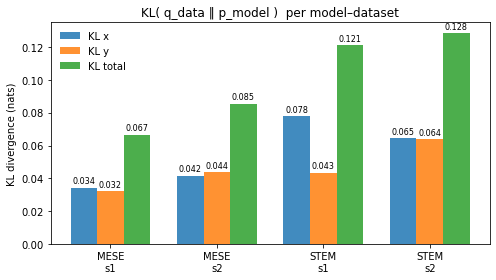

In [82]:
keys   = list(kl_results.keys())
labels = [f"{dd}\ns{seed}" for dd, seed in keys]
kl_x   = [kl_results[k]['kl_x']     for k in keys]
kl_y   = [kl_results[k]['kl_y']     for k in keys]
kl_tot = [kl_results[k]['kl_total'] for k in keys]

x      = np.arange(len(keys))
width  = 0.25

fig, ax = plt.subplots(figsize=(7, 4))
bars_x   = ax.bar(x - width,    kl_x,   width, label='KL x', color=clrs[0], alpha=0.85)
bars_y   = ax.bar(x,            kl_y,   width, label='KL y', color=clrs[1], alpha=0.85)
bars_tot = ax.bar(x + width,    kl_tot, width, label='KL total', color=clrs[2], alpha=0.85)

# value labels on bars
for bars in [bars_x, bars_y, bars_tot]:
    for bar in bars:
        h = bar.get_height()
        ax.text(bar.get_x() + bar.get_width() / 2, h + 0.01 * max(kl_tot),
                f'{h:.3f}', ha='center', va='bottom', fontsize=8)

ax.set_xticks(x)
ax.set_xticklabels(labels)
ax.set_ylabel('KL divergence (nats)')
ax.set_title('KL( q_data ‖ p_model )  per model–dataset')
ax.legend(frameon=False)
ax.axhline(0, color='k', linewidth=0.5)
plt.tight_layout()
plt.savefig('Plots/KL_divergence_bar.pdf', bbox_inches='tight')
plt.show()

In [83]:
# --- Cross-evaluation: KL total for each model on all 4 datasets ---
# Models: MESE s1, MESE s2, STEM s1, STEM s2
# Each evaluated on: own val set, opposite-seed same-type, same-seed opposite-type, opposite-seed opposite-type

cross_eval_keys = [
    # (model_key,       data_key,        bar_label)
    (('MESE', 2), ('MESE', 2), 'MESE-m1\nMESE-d1'),   # own
    (('MESE', 2), ('MESE', 1), 'MESE-m1\nMESE-d2'),   # opp seed
    (('MESE', 2), ('STEM', 1), 'MESE-m1\nSTEM-d2'),   # opp type, opp seed

    (('STEM', 2), ('STEM', 2), 'STEM-m1\nSTEM-d1'),   # own
    (('STEM', 2), ('STEM', 1), 'STEM-m1\nSTEM-d2'),   # opp seed
    (('STEM', 2), ('MESE', 1), 'STEM-m1\nMESE-d2'),   # opp type, opp seed
]

bar_labels = [c[2] for c in cross_eval_keys]
kl_vals    = []

for model_key, data_key, _ in cross_eval_keys:
    res = compute_kl_divergence(models[model_key], val_sets[data_key], verbose=False)
    kl_vals.append(res['kl_total'])


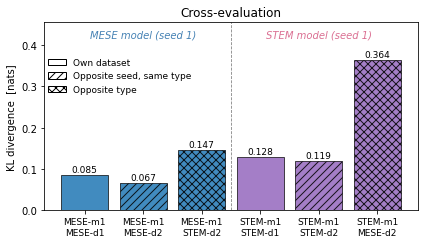

In [84]:
# hatch patterns: own=none, opposite seed=diagonal, opposite type=crosshatch
hatches    = ['', '///', 'xxx',   '', '///', 'xxx']
bar_colors = ['tab:blue']*3 + ['tab:purple']*3
edgecolors = ['black']*3 + ['black']*3

fig, ax = plt.subplots(figsize=(6, 3.5))
bars = ax.bar(np.arange(6), kl_vals, color=bar_colors, hatch=hatches,
              edgecolor=edgecolors, linewidth=0.8, alpha=0.85)

for bar, val in zip(bars, kl_vals):
    ax.text(bar.get_x() + bar.get_width()/2, val + 0.005 * max(kl_vals),
            f'{val:.3f}', ha='center', va='bottom', fontsize=9)

ax.axvline(2.5, color='gray', linestyle='--', linewidth=0.8)

ax.set_ylim(top=max(kl_vals) * 1.25)
ax.text(1.0, ax.get_ylim()[1]*0.92, 'MESE model (seed 1)', ha='center', fontsize=10, style='italic', color='steelblue')
ax.text(4.0, ax.get_ylim()[1]*0.92, 'STEM model (seed 1)', ha='center', fontsize=10, style='italic', color='palevioletred')

ax.set_xticks(np.arange(6))
ax.set_xticklabels(bar_labels, fontsize=9)
ax.set_ylabel('KL divergence  [nats]')
ax.set_title('Cross-evaluation')
ax.axhline(0, color='k', linewidth=0.5)

from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor='white', edgecolor='black', hatch='',    label='Own dataset'),
    Patch(facecolor='white', edgecolor='black', hatch='///', label='Opposite seed, same type'),
    Patch(facecolor='white', edgecolor='black', hatch='xxx', label='Opposite type'),
]
ax.legend(handles=legend_elements, frameon=False, fontsize=9, loc=[0, 0.6])

plt.tight_layout()
plt.savefig('Plots/KL_cross_evaluation.png', bbox_inches='tight', dpi=600)
plt.show()

In [114]:
# --- Force term ablation study: MESE seed 1 val set ---
# All models evaluated on the same val_data (last 140 frames of MESE s1)
# Colour scheme: shades of cyan-green (teal family) for mesenchymal

# ablation_models = {
#     'Full model\n(no Fenv)':      'modelFenvPytorch_TauInit10_Mese1_Rcut100_FarFieldR100_200Epochs_NoFenv_Naive',
#     'With Fenv':                  'modelFenvPytorch_TauInit10_Mese_Rcut100_FarFieldR0_Naive',
#     'With Fenv\n(no drag)':       'modelFenvPytorch_TauInit10_Mese1_Rcut100_FarFieldR100_200Epochs_Fenv_NoDrag_Naive',
#     'With Fenv\n(no interaction)':'modelFenvPytorch_TauInit10_Mese1_Rcut100_FarFieldR100_200Epochs_Fenv_NoInt_Naive',
# }

ablation_models = {
    'Main model\n(no Fenv)':      'modelFenvPytorch_TauInit10_Mese1_Rcut100_FarFieldR100_200Epochs_NoFenv_Naive',
    'With Fenv':                  'modelFenvPytorch_TauInit10_Mese_Rcut100_FarFieldR0_Naive',
    'With Fenv\n(no drag)':       'modelFenvPytorch_TauInit10_Mese1_Rcut100_FarFieldR100_200Epochs_NoFenv_NoDrag_Naive',
    'With Fenv\n(no interaction)':'modelFenvPytorch_TauInit10_Mese1_Rcut100_FarFieldR100_200Epochs_NoFenv_NoInt_Naive',
}

teal_shades = ['#1a7a6e', '#2aab99', '#6dcfc4', '#b0e8e2']

ablation_kl   = []
ablation_labels = list(ablation_models.keys())
c=0
for label, name in ablation_models.items():
    if c==1:
        m = load_model_env(datasave + name, hidden_dim=64)
    else:
        m = load_model(datasave + name, hidden_dim=64)
    c+=1
    res = compute_kl_divergence(m, val_sets[('MESE', 1)], verbose=False)
    ablation_kl.append(res['kl_total'])
    print(f"{label.replace(chr(10),' '):40s}  KL = {res['kl_total']:.4f}")



Loaded config from: //Users/billiemeadowcroft/Dropbox/PostDocCode/GNN/My_GNN/CellStatTransitionPytorch/models/modelFenvPytorch_TauInit10_Mese1_Rcut100_FarFieldR100_200Epochs_NoFenv_Naive_config.json
Weights loaded from: //Users/billiemeadowcroft/Dropbox/PostDocCode/GNN/My_GNN/CellStatTransitionPytorch/models/modelFenvPytorch_TauInit10_Mese1_Rcut100_FarFieldR100_200Epochs_NoFenv_Naive.pt
Normalisation restored: r_mean=66.3496, r_std=23.279
  hidden_dim=64, tau=0.191900
Main model (no Fenv)                      KL = 0.0676
Loaded config from: //Users/billiemeadowcroft/Dropbox/PostDocCode/GNN/My_GNN/CellStatTransitionPytorch/models/modelFenvPytorch_TauInit10_Mese_Rcut100_FarFieldR0_Naive_config.json
Weights loaded from: //Users/billiemeadowcroft/Dropbox/PostDocCode/GNN/My_GNN/CellStatTransitionPytorch/models/modelFenvPytorch_TauInit10_Mese_Rcut100_FarFieldR0_Naive.pt
Normalisation restored: r_mean=66.3496, r_std=23.279
  hidden_dim=64, tau=68.082512
With Fenv                              

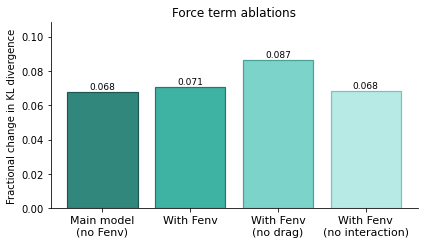

In [113]:
fig, ax = plt.subplots(figsize=(6, 3.5))
bars = ax.bar(np.arange(4), ablation_kl, color=teal_shades,
              edgecolor=[c for c in teal_shades],
              linewidth=1.2, alpha=0.9)

# darken edge colours slightly relative to fill
dark_edges = ['#0f4d45', '#1a6b5e', '#3d9990', '#6abfb8']
for bar, ec in zip(bars, dark_edges):
    bar.set_edgecolor(ec)
count = 0
for bar, val in zip(bars, ablation_kl):
    ax.text(bar.get_x() + bar.get_width()/2, val + 0.005 * max(ablation_kl),
            f'{val:.3f}', ha='center', va='bottom', fontsize=9)

ax.set_xticks(np.arange(4))
ax.set_xticklabels(ablation_labels, fontsize=11)
ax.set_ylim(0, max(ablation_kl) * 1.25)
ax.set_ylabel('Fractional change in KL divergence')
ax.set_title('Force term ablations', fontsize=12)
ax.axhline(0, color='k', linewidth=0.5)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.savefig('Plots/KL_ablation_MESE.png', bbox_inches='tight', dpi=600)
plt.show()

Reference sigma:  x=0.8553  y=0.8593
Global sigma:  sigma_x=0.855271  sigma_y=0.859283
Frames processed: 276  |  valid (>=5 nodes): 276
Mean KL_total (valid frames): 0.4128
Global sigma:  sigma_x=0.855271  sigma_y=0.859283
Frames processed: 276  |  valid (>=5 nodes): 276
Mean KL_total (valid frames): 0.3285


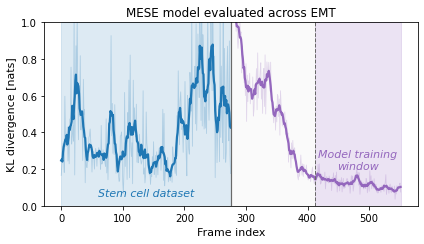

In [106]:
# --- KL divergence per frame: MESE model (s1) on MESE data (s1) stitched
#     with MESE model (s1) on STEM data (s2) ---
#
# The MESE model was trained on the FIRST portion of its dataset, so the
# MESE val_set here is frames from the second portion of MESE (in-distribution).
# The STEM val_set (seed 2) is entirely out-of-distribution for this model.
#
# We estimate sigma once from the MESE model's own val set so the noise
# scale is consistent across both segments.

import importlib
import KL_divergence
importlib.reload(KL_divergence)
from KL_divergence import compute_kl_per_frame

# --- estimate a shared sigma from the in-distribution val set ---
from KL_divergence import _collect_predictions_and_targets, _estimate_noise_std
pred_ref, targ_ref = _collect_predictions_and_targets(models[('MESE', 1)], val_sets[('MESE', 1)])
sigma_ref = _estimate_noise_std(pred_ref, targ_ref)
print(f"Reference sigma:  x={sigma_ref[0]:.4f}  y={sigma_ref[1]:.4f}")


nameSave_DataIN = "dataIn_MESE_Naive_Rcut100_seed1.pkl"

min_target_std = 0.01   # adjust if needed — well below any real frame (~1.0)

with open(save_path / nameSave_DataIN, 'rb') as f:
    data_loaded_full = pickle.load(f)
mese_all_data = data_loaded_full["dataset"]   # all frames, no split

mese_all_data = [
    dp for dp in mese_all_data
    if np.std(dp['targets']) > min_target_std
]

nameSave_DataIN = "dataIn_STEM_Naive_Rcut100_seed2.pkl"

with open(save_path / nameSave_DataIN, 'rb') as f:
    data_loaded_full = pickle.load(f)
stem_all_data = data_loaded_full["dataset"]   # list of dicts
#stem_all_data = stem_all_data[30:]

#stem_all_data = data_loaded_full["dataset"]
stem_all_data = [
    dp for dp in stem_all_data
    if np.std(dp['targets']) > min_target_std
]

# Sort by frame ID so x-axis is chronological
stem_all_data_sorted = sorted(stem_all_data, key=lambda dp: dp.get('frame', 0))
mese_all_data_sorted = sorted(mese_all_data, key=lambda dp: dp.get('frame', 0))

kl_stem_seg = compute_kl_per_frame(
    models[('MESE', 1)], stem_all_data_sorted,
    global_sigma=sigma_ref, verbose=True
)
kl_mese_all = compute_kl_per_frame(
    models[('MESE', 1)], mese_all_data_sorted,
    global_sigma=sigma_ref, verbose=True
)
n_stem     = len(kl_stem_seg['frame_ids'])
n_mese_all = len(kl_mese_all['frame_ids'])
train_window_start = n_mese_all - 140   # last 140 = training data

# stitched x-axes
x_stem_seg  = np.arange(n_stem)
x_mese_all  = np.arange(n_stem, n_stem + n_mese_all)
x_train_start = n_stem + train_window_start   # absolute x where training window begins

# ---- plot ----
fig, ax = plt.subplots(figsize=(6, 3.5))

# background shading
ax.axvspan(x_stem_seg[0],   x_stem_seg[-1],    alpha=0.15, color='tab:blue',   zorder=0)
ax.axvspan(x_mese_all[0],   x_train_start,     alpha=0.04, color='gray',       zorder=0)   # MESE pre-training
ax.axvspan(x_train_start,   x_mese_all[-1],    alpha=0.18, color='tab:purple',   zorder=0)   # training window

# raw traces (faint)
ax.plot(x_stem_seg, kl_stem_seg['kl_total'], color='tab:blue',        alpha=0.25, linewidth=0.8)
ax.plot(x_mese_all, kl_mese_all['kl_total'], color='tab:purple', alpha=0.25, linewidth=0.8)

# smoothed traces
ax.plot(x_stem_seg, smooth(kl_stem_seg['kl_total'], w=7),
        color='tab:blue',        linewidth=2.2, label='MESE model — STEM data (s2)')
ax.plot(x_mese_all, smooth(kl_mese_all['kl_total'], w=7),
        color='tab:purple', linewidth=2.2, label='MESE model — MESE data (all frames, s1)')

# stitch boundary (STEM | MESE)
ax.axvline(n_stem - 0.5, color='dimgray', linestyle='-', linewidth=1.2)

# training window boundary
ax.axvline(x_train_start - 0.5, color='dimgray', linestyle='--', linewidth=1.0)

# region labels (positioned like the sketch)
ymax = ax.get_ylim()[1]
ax.set_ylim(bottom=0, top=ymax * 1.25)   # headroom for labels
ymax = ax.get_ylim()[1]

ax.text((x_stem_seg[0] + x_stem_seg[-1]) / 2, 0.05,
        'Stem cell dataset', ha='center', fontsize=11, color='tab:blue', style='italic')

ax.text(x_train_start + (x_mese_all[-1] - x_train_start) / 2, 0.2,
        'Model training\nwindow', ha='center', fontsize=11, color='tab:purple', style='italic')

ax.set_xlabel('Frame index', fontsize=11)
ax.set_ylabel('KL divergence [nats]', fontsize=11)
ax.set_title('MESE model evaluated across EMT', fontsize=12)
#ax.legend(frameon=False, fontsize=9, loc='upper right')
ax.set_ylim([0,1])
plt.tight_layout()
plt.savefig('Plots/KL_per_frame_stitched.png', bbox_inches='tight',dpi=600)
plt.show()

In [55]:
# Check what's happening in the early spike frames
spike_idx = np.nanargmax(kl_mese_all['kl_total'])
dp = mese_all_data[spike_idx]

print(f"Spike at list index {spike_idx}, frame id {dp.get('frame', spike_idx)}")
print(f"  n nodes in frame:        {np.sum(dp['mask'] == 1.0) if 'mask' in dp else len(dp['nodes'])}")
print(f"  n_nodes array (first 10): {kl_mese_all['n_nodes'][:10]}")
print(f"  KL values (first 10):     {np.round(kl_mese_all['kl_total'][:10], 3)}")

# Also check targets in spike frame vs a normal frame
normal_idx = np.nanargmin(np.abs(kl_mese_all['kl_total'] - np.nanmedian(kl_mese_all['kl_total'])))
print(f"\nSpike frame target stats:  mean={dp['targets'].mean(axis=0)}, std={dp['targets'].std(axis=0)}")
dp_normal = mese_all_data[normal_idx]
print(f"Normal frame target stats: mean={dp_normal['targets'].mean(axis=0)}, std={dp_normal['targets'].std(axis=0)}")

Spike at list index 33, frame id 278
  n nodes in frame:        117
  n_nodes array (first 10): [147 196 256 334 200 290 375 176 317 300]
  KL values (first 10):     [0.725 0.311 0.118 0.164 0.316 0.099 0.098 0.458 0.128 0.131]

Spike frame target stats:  mean=[-2.0267835e-07  1.4058749e-07], std=[3.8885382e-06 4.1707094e-06]
Normal frame target stats: mean=[0.0290389  0.03028808], std=[1.1614151 1.1965363]


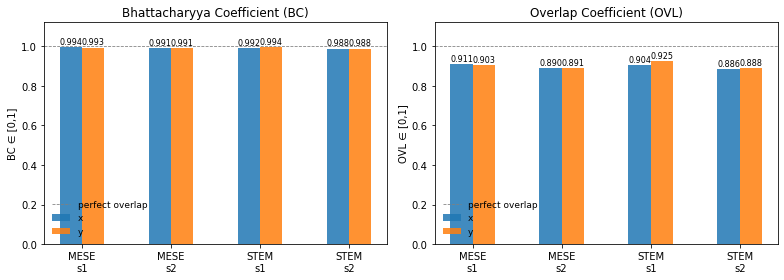

In [25]:
bc_x    = [overlap_results[k]['bc_x']   for k in keys]
bc_y    = [overlap_results[k]['bc_y']   for k in keys]
ovl_x   = [overlap_results[k]['ovl_x']  for k in keys]
ovl_y   = [overlap_results[k]['ovl_y']  for k in keys]

fig, axes = plt.subplots(1, 2, figsize=(11, 4), sharey=False)

for ax, vals_x, vals_y, title, ylabel in [
    (axes[0], bc_x,  bc_y,  'Bhattacharyya Coefficient (BC)',   'BC ∈ [0,1]'),
    (axes[1], ovl_x, ovl_y, 'Overlap Coefficient (OVL)',        'OVL ∈ [0,1]'),
]:
    bx = ax.bar(x - width/2, vals_x, width, label='x', color=clrs[0], alpha=0.85)
    by = ax.bar(x + width/2, vals_y, width, label='y', color=clrs[1], alpha=0.85)
    for bars in [bx, by]:
        for bar in bars:
            h = bar.get_height()
            ax.text(bar.get_x() + bar.get_width() / 2, h + 0.005,
                    f'{h:.3f}', ha='center', va='bottom', fontsize=8)
    ax.set_xticks(x)
    ax.set_xticklabels(labels)
    ax.set_ylim(0, 1.12)
    ax.axhline(1.0, color='gray', linestyle='--', linewidth=0.8, label='perfect overlap')
    ax.set_ylabel(ylabel)
    ax.set_title(title)
    ax.legend(frameon=False, fontsize=9)

plt.tight_layout()
#plt.savefig('Plots/overlap_metrics_bar.pdf', bbox_inches='tight')
plt.show()

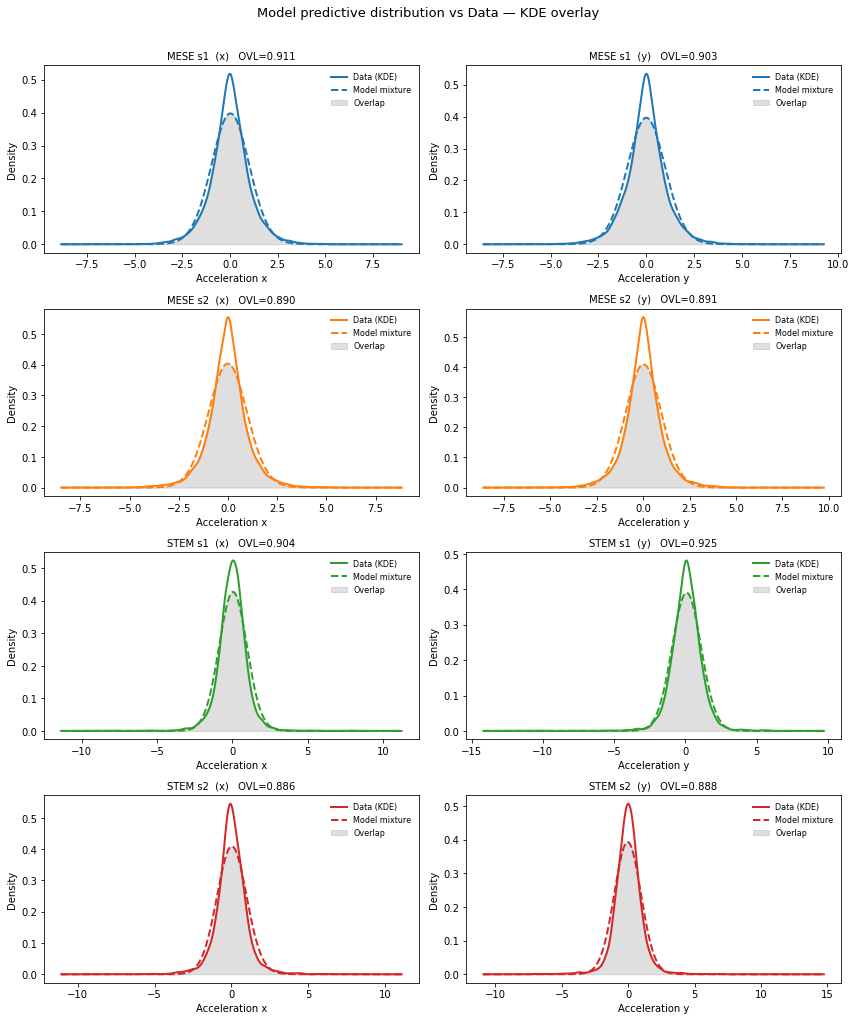

In [26]:
def _mixture_pdf(y_grid, mu, sigma):
    """Evaluate model Gaussian-mixture pdf on a 1-D grid."""
    diff      = y_grid[:, None] - mu[None, :]       # (M, N)
    log_comps = -0.5*(diff/sigma)**2 - np.log(sigma) - 0.5*np.log(2*np.pi)
    max_lc    = log_comps.max(axis=1, keepdims=True)
    log_mix   = max_lc[:, 0] + np.log(np.exp(log_comps - max_lc).sum(axis=1)) - np.log(len(mu))
    return np.exp(log_mix)


def plot_kde_overlap(ax, targets_dim, predictions_dim, sigma, label, color_data, color_model, dim_name):
    """Plot overlaid KDE curves with shaded overlap for one dimension."""
    lo = min(targets_dim.min(), predictions_dim.min()) - 4*sigma
    hi = max(targets_dim.max(), predictions_dim.max()) + 4*sigma
    y_grid = np.linspace(lo, hi, 512)

    kde_data  = gaussian_kde(targets_dim)
    q_vals    = kde_data.evaluate(y_grid)
    p_vals    = _mixture_pdf(y_grid, predictions_dim, sigma)

    ax.plot(y_grid, q_vals, color=color_data,  lw=2.0, label='Data (KDE)')
    ax.plot(y_grid, p_vals, color=color_model, lw=2.0, linestyle='--', label='Model mixture')
    ax.fill_between(y_grid, np.minimum(q_vals, p_vals), alpha=0.25, color='gray', label='Overlap')

    ovl = float(np.trapz(np.minimum(q_vals, p_vals), y_grid))
    ax.set_title(f"{label}  ({dim_name})   OVL={ovl:.3f}", fontsize=10)
    ax.set_xlabel(f'Acceleration {dim_name}')
    ax.set_ylabel('Density')
    ax.legend(frameon=False, fontsize=8)


n_models = len(keys)
fig, axes = plt.subplots(n_models, 2, figsize=(12, 3.5 * n_models))
if n_models == 1:
    axes = axes[np.newaxis, :]

for row, key in enumerate(keys):
    dd, seed = key
    res      = kl_results[key]          # has predictions, targets, sigma_x, sigma_y
    label    = f"{dd} s{seed}"

    for col, (dim, dim_name, sigma) in enumerate([
        (0, 'x', res['sigma_x']),
        (1, 'y', res['sigma_y']),
    ]):
        plot_kde_overlap(
            ax             = axes[row, col],
            targets_dim    = res['targets'][:, dim],
            predictions_dim= res['predictions'][:, dim],
            sigma          = sigma,
            label          = label,
            color_data     = clrs[row],
            color_model    = clrs[row],
            dim_name       = dim_name,
        )

plt.suptitle('Model predictive distribution vs Data — KDE overlay', fontsize=13, y=1.01)
plt.tight_layout()
#plt.savefig('Plots/kde_overlap_per_model.pdf', bbox_inches='tight')
plt.show()

In [27]:
import pandas as pd

rows = []
for key in keys:
    dd, seed = key
    kl  = kl_results[key]
    ov  = overlap_results[key]
    rows.append({
        'Model':       f"{dd} s{seed}",
        'sigma_x':     f"{kl['sigma_x']:.4f}",
        'sigma_y':     f"{kl['sigma_y']:.4f}",
        'KL_x':        f"{kl['kl_x']:.4f}",
        'KL_y':        f"{kl['kl_y']:.4f}",
        'KL_total':    f"{kl['kl_total']:.4f}",
        'BC_x':        f"{ov['bc_x']:.4f}",
        'BC_y':        f"{ov['bc_y']:.4f}",
        'OVL_x':       f"{ov['ovl_x']:.4f}",
        'OVL_y':       f"{ov['ovl_y']:.4f}",
        'Hellinger_x': f"{ov['hellinger_x']:.4f}",
        'Hellinger_y': f"{ov['hellinger_y']:.4f}",
    })

df = pd.DataFrame(rows).set_index('Model')
df

,sigma_x,sigma_y,KL_x,KL_y,KL_total,BC_x,BC_y,OVL_x,OVL_y,Hellinger_x,Hellinger_y
Model,,,,,,,,,,,
MESE s1,0.8553,0.8593,0.0318,0.0359,0.0676,0.9936,0.9929,0.9108,0.9034,0.0798,0.0840
MESE s2,0.8542,0.8390,0.0486,0.0458,0.0944,0.9905,0.9908,0.8899,0.8909,0.0975,0.0958
STEM s1,0.8498,0.9352,0.0604,0.0541,0.1145,0.9918,0.9936,0.9036,0.9248,0.0907,0.0800
STEM s2,0.8846,0.9244,0.0829,0.0868,0.1696,0.9878,0.9876,0.8860,0.8879,0.1105,0.1115
